In [8]:
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt

# 1. About the Data & Preprocessing

The data we are going to use consist of two parts <br>
TESS Input Catalog and MAST Archive 

### 1.1. TESS Input Catalog 
This list contains the star names (tid) and the labels for the classifier (tfopwg_disp) <br>
Downloaded through Nasa Exoplanet Archive.<br>
Link: <a>https://exoplanetarchive.ipac.caltech.edu/index.html</a>


In [9]:
import pandas as pd
df = pd.read_csv("toi_data.csv")
df = df[["tid", "tfopwg_disp"]]
df = df[df["tfopwg_disp"].isin(["CP", "FP"])].copy()
df["tfopwg_disp"].value_counts()

tfopwg_disp
FP    1228
CP     705
Name: count, dtype: int64

### 1.2. MAST Archive ve Lightkurve
The lightcurve data is in MAST (Mikulski Archive for Space Telescopes) and we are using Python Lightcurve library to download and process. <br>
As an example we are going to focus on Pi Mensae C. A clean and confirmed exoplanet signal. <br>

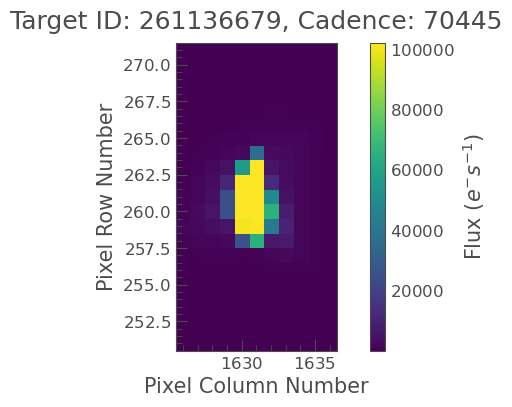

In [10]:
import lightkurve as lk
# parameters
# id for Pi Mensae C
# mission = TESS data
# SPOC preprocessed and cleaned data by NASA
tpf = lk.search_targetpixelfile("TIC 261136679", mission="TESS", author="SPOC").download()

# Plot the pixels
tpf.plot()
plt.show()  

The data we need is the flux value. <br>
Transit method: The planet blocks some of the host stars light while passing between the telescope and the host star. <br> 
This translates to a lower flux value on the telescope instruments.

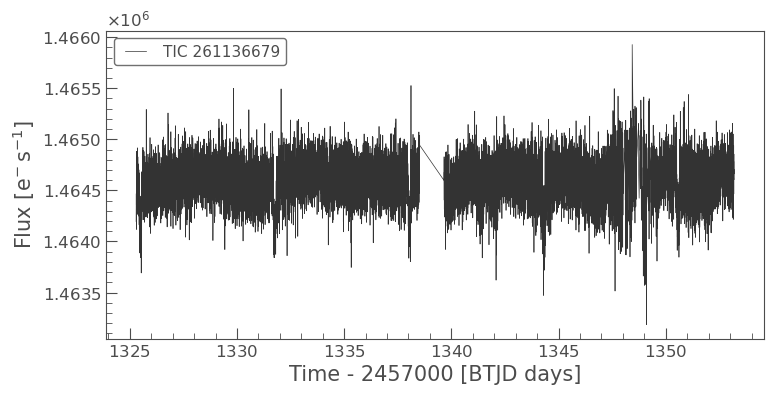

In [11]:

# download the lightcurve
search_result = lk.search_lightcurve("TIC 261136679", mission="TESS", author="SPOC") # 261136679
lc = search_result.download()
lc.plot()
plt.show()

The data spans around 27 days. This is because the orbit of the telecope around Earth. Also it sends data once every 13 days. This is the reason for the gaps in the data.

The noise in the data is instrumental and environmental noise. <br>  
The telecope sensitivity, orbit around Earth, wobbling and vibrating, background stars are contributing factors to this noise.

We first remove the empty data.<br>
Then we pick the best quality data that is flagged by nasa. <br>
We remove outliers.

The light coming from the stars are irregular and non-static. It fluctuates greatly over time. <br>
So we flatten the lightcurve to correct for this fluctuation using .flatten().

Flatten applies Savitzky-Golay filter to smooth out the data.
We are trying to reduce the noise while keeping the shape of the data.

https://scipy.github.io/old-wiki/pages/Cookbook/SavitzkyGolay


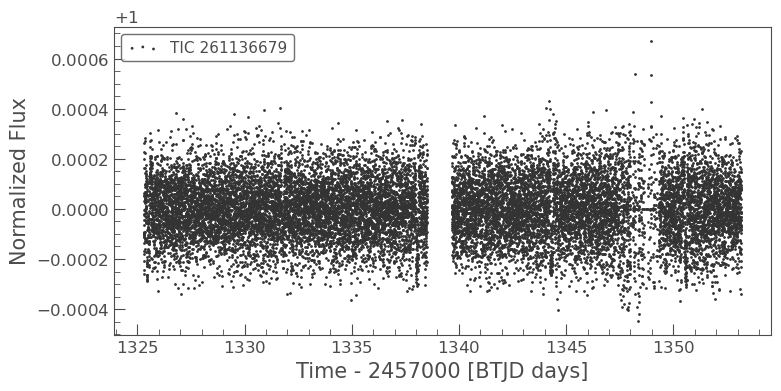

In [12]:

lc = lc.remove_nans() 
lc = lc[lc.quality == 0] # quality control
lc = lc.remove_outliers(sigma = 3) # remove the observations that are 3 sigmas away from the mean
# parameters
# window_length: number of points used for moving average calculation
# why 401 is chosen: it is a rule of thumb with the TESS data
# this is small enough to remove long-term trends but large enough not to remove the transit signal
flat_lc = lc.flatten(window_length=401)
flat_lc.scatter()
plt.show()  

The next step is to search for a dip in the data <br>
We need to know the transit period of the planet <br>
We use bls algorightm to find it <br>
The period of the host star is 6.27 but the algorithm will find it for us. <br> 

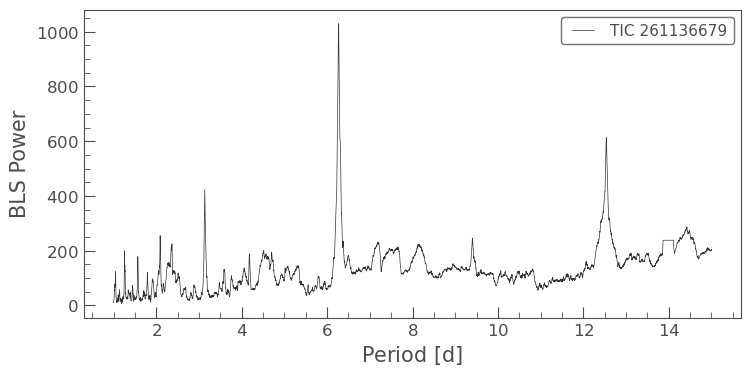

In [13]:
import numpy as np
pg = lc.to_periodogram(method="bls", period=np.linspace(1, 15, 5000)) # box least squares
pg.plot()
plt.show()

Periyodu bulduktan sonra periyodun ilk keşfedildiği zamandan başlayarak veriyi "katlamamız" gerekiyor.<br>
We need to "fold" data from the transit period the BLS algorithm found. <br>
We also bin the data to reduce noise. <br>
This is what we feed into the classifier model along with statistical features of the lightcurve. <br>
This way the transit signals will overlap with itself and the transit will be more visible. <br>

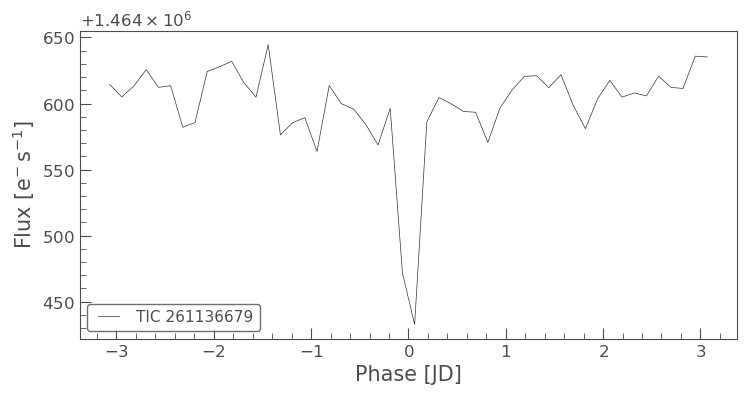

In [14]:
best_period = pg.period_at_max_power.value # Best period
best_t0 = pg.transit_time_at_max_power.value # Best epoch time (start of the period)
folded_lc = lc.fold(period=best_period, epoch_time=best_t0)
folded_lc = folded_lc.bin(bins=50) # binning to reduce noise
folded_lc.plot()
plt.show()

# 2. Feature Extraction
We choose the below statistical features alongside the flux data.<br>
Standard deviation, <br>
Skewness, must be negative in the exoplanet signal <br>
Kurtosis <br>

Coming from the BLS algorithm:<br>
Period,<br>
Transit depth (derinlik), indicates how much the exoplanet blocks the host stars light. This the feature used to estimate the size of the exoplanet. <br>
Max power, the peak point in the BLS periodogram, power of the signal<br>

This is what the data looks like after the feature extraction.

In [15]:
import pandas as pd
features = pd.read_pickle("extracted_features.pkl")
# display first 9 columns and last 2 columns
features = features.iloc[:, list(range(9)) + [-2, -1]]
features.head()

,std_dev,skewness,kurtosis,period,transit_depth,transit_duration,max_power,flux_0,flux_1,flux_49,target
0,0.001820,0.003804,-0.168127,12.409482,0.000235,0.05,2.205922,0.999995,0.9999998166223942,1.000003,0
1,0.001591,0.010904,-0.147384,1.868174,0.000093,0.05,4.580811,0.999998,0.9999938580887549,0.999983,0
2,0.000728,0.054569,-0.118460,2.744749,0.000280,0.10,40.896649,0.999960,1.0000520450597414,0.999968,0
3,0.001402,0.001151,-0.179032,11.373275,0.000145,0.05,2.169721,1.000006,0.9999923744428908,1.000003,0
4,0.001545,0.006737,-0.117861,4.551110,0.000172,0.10,13.378276,0.999997,1.0000123763028184,1.000004,0


Exculuded some flux features for better visibility. There are 50 flux features starting from 0 to 49.

# 3. Fine Tuning
We used Randomized Search for fine tuning. <br>
We remove nans and non-numerical data as best practice. <br>
Empty observations are filled with mean using simple imputer. <br>

<b>Chosen Parameter Distributions</b>

<img src="results\param_distros.png" alt="2" style="width: 500px">
<img src="results\param_distros2.png" alt="2" style="width: 700px">


### 3.1. Class Imbalance
Exoplanet transits occur very rarely due to the physical constraints of the TESS telescope. <br>
The maximum planetary orbital period observable via the transit method using TESS is 13.5 days.<br>
However, as we know from our own solar system, even the planet closest to our star has a period of 88 days.<br>
Due to this limitation and the prevalence of binary star systems, there is an imbalance in the dataset.<br>
This imbalance was addressed within the pipeline using the SMOTE (Synthetic Minority Over-sampling Technique) method, by simulating minority observations exclusively in the training set.

In [16]:
# Class distribution 0: 984, 1: 692
# Approximately 58.7% negative (0) and 41.3% positive (1)
features["target"].value_counts()

target
0    984
1    692
Name: count, dtype: int64

### 3.2 Randomized Search

Randomized search için 30 hiperparametre kombinasyonu, <br>
30 hyper-parameter combinations for Randomized Search <br>
5-fold Cross Validation, <br>
F1 Score for performance measurements.

<b> Pipeline </b>

<img src="results\pipeline.png" alt="2" style="width: 700px">

### 3.3. Results and Decision Treshold Optimisation

"Due to the class imbalance in the dataset, the default decision threshold of 0.5 is insufficient for the problem at hand. When generating predictions, a model typically selects the class with a probability exceeding 0.5; this cut-off point is known as the decision threshold.

Imagine you are the scientist overseeing the machine learning model in this project. <br>
If a light curve is fed into a model with a standard 0.5 threshold and the model assigns it a positive probability of 0.4, it will predict a 'negative' result, causing you to discard that potential candidate. However, if that light curve actually has a real planet, that discovery is effectively lost to science until a future telescope observation occurs. <br> 
A 40% probability is actually quite significant for an exoplanet candidate, and from a scientific standpoint, this is a possibility we cannot afford to miss. 

Therefore, the decision thresholds of the best models trained via Randomized Search were processed through an optimization algorithm to identify and update the optimal threshold for each model. 

The final performance results obtained following decision threshold optimization are as follows:" 


In [17]:
results = pd.read_csv("results/final_performance_report.csv")
best_params = results["Best Params"]
results.drop(columns=["Best Params"], inplace=True)
results.to_excel("results/final_performance_report.xlsx", index=False)
results


,Model,Best CV Score (F1),Best Threshold,Precision,Recall,New F1
0,Random Forest,0.628,0.48,0.630,0.713,0.669
1,SVM,0.618,0.40,0.516,0.902,0.657
2,Gradient Boosting,0.611,0.44,0.540,0.828,0.654
3,KNN,0.612,0.54,0.564,0.762,0.648
4,Logistic Regression,0.609,0.50,0.526,0.820,0.641
5,Decision Tree,0.596,0.10,0.445,0.967,0.610


### 3.4 Best Parameters of the First Model

In [18]:
import pprint
pprint.pprint(best_params[0], width=40)

("{'model__bootstrap': True, "
 "'model__criterion': 'gini', "
 "'model__max_depth': 23, "
 "'model__max_features': None, "
 "'model__min_samples_leaf': 9, "
 "'model__min_samples_split': 16, "
 "'model__n_estimators': 114}")


### 3.5. Feature Importance

<img src="results/shap_beeswarm.png" alt="2" style="width: 500px">

We measured feature importance with SHAP.

Here, the feature "flux_28" stands out as the model's most strongly discriminating feature. This feature corresponds to the 28th bin in the dataset, which was binned to reduce noise following the data folding process. After the period is determined using the BLS method, the folding algorithm aligns the planetary signal to be centered within the light curve. While the transit signal is strongest around bins 24 and 26, the greatest contribution to the decision comes from the 28th bin. When this specific bin is plotted, we can see that the values cluster around 1.

<img src="results\flux_28_analysis_train_data.png" alt="2" style="width: 500px">

So, while the 28th bin is located near the center of the folded light curve, the values it contains present a somewhat counterintuitive result. This indicates that the Random Forest model analyzes not only scalar statistics—such as depth, period, and transit duration—but also the morphology of the transit itself. Here, we identify the 'period' as the model's second strongest discriminating feature. This highlights that a fundamental characteristic of planetary transit signals is their repetition at regular and consistent intervals, as opposed to random noise. The model utilized this periodicity, detected by the BLS algorithm, as a primary filter to distinguish exoplanets from instrumental errors and noise.

### 3.6. Confusion Matrix

Random Forest model yields the best overall score; however, the Support Vector Machine (SVM), actually identifies more planets and overlooks fewer of them. As previously discussed, while the primary objective is to minimize missed planetary candidates, we must also avoid the pitfall of classifying every signal as a planet as observed with the Decision Tree model. False positives can typically be ruled out upon closer inspection by a trained eye. In this respect, the Support Vector Machine, with its superior Recall score, may be more advantageous for ensuring that potential planetary discoveries are not missed.

Alternatively, we could create a Cascade Model by feeding the data flagged as 'planet' by the SVM into the Random Forest model, which possesses higher Precision. Another option would be to construct a new Ensemble Model combining these two, utilizing the Soft Voting technique to refine the predictions.


<table>
  <tr>
    <td><img src="results\confusion_matrix_random_forest.png" alt="1" style="width: 500px"></td>
    <td><img src="results\confusion_matrix_svm.png" alt="2" style="width: 500px"></td>
    
  </tr>
</table>
 

# 4. Cascade Classifier Model
In the Cascade model configuration, the positive predictions generated by the Support Vector Machine (which possessed a higher Recall score of 0.902) were fed into the Random Forest model (characterized by a higher Precision score of 0.630). Following the modeling process, the resulting Cascade Classifier Model exhibited a decrease in Recall; however, its Precision score surpassed the individual scores of both constituent models. Consequently, the F1 score increased from 66.9% (Random Forest) to 67.2% (an increase of %0.3).

In [19]:
cascade_result = pd.read_csv("cascade_metrics_report_shape.csv")
cascade_result

,Model,Best Threshold,Precision,Recall,F1 Score
0,Cascade Classifier (SVM+RF),-,0.649,0.697,0.672


### 4.1. Confusion Matrix
Although the Cascade model achieved a higher F1 score, it falls behind both of the previously successful models regarding our primary objective of maximizing exoplanet discovery.<br>


<img src="results/cascade_confusion_matrix.png" alt="2" style="width: 500px">

# 5. Soft Voting Ensemble Model

Another approach to combine the performance of the two most successful models is the Ensemble Method. <br> 
In this method, we aggregate the two models and enable them to reach a consensus using a technique called Soft Voting. <br> 
The Ensemble model operates using default decision thresholds. The predicted probabilities for Class 1 (exoplanet) are retrieved from both models. These probabilities are summed and divided by two. The resulting average becomes the new predicted probability for the Ensemble model. <br> 
If this probability exceeds the Decision Threshold, the model generates a positive prediction. Following this calculation, we applied the decision threshold optimization algorithm to the Ensemble model and identified the new optimal decision threshold as 0.46.


In [20]:
ensemble_result = pd.read_csv("ensemble_metrics_report.csv")
ensemble_result

,Model,Best Threshold,Precision,Recall,F1 Score
0,Voting Ensemble (RF+SVM),0.46,0.589,0.787,0.674


## 5.1. Ensemble Confusion Matrix
While the Ensemble Model detects a greater number of exoplanets (96) compared to the Random Forest model (87), it simultaneously mitigates the high false positive rate associated with the Support Vector Machine. <br> 
In this way, we successfully combined strengths of both models. 

<img src="results/ensemble_confusion_matrix.png" alt="2" style="width: 500px">

# 6. Final Results

In [ ]:
rf_svm = results[results["Model"].isin(["Random Forest", "SVM"])]
rf_svm = rf_svm[["Model", "Best Threshold", "Precision", "Recall", "New F1"]]
rf_svm = rf_svm.rename(columns={"New F1": "F1 Score"})
final_result = [rf_svm, cascade_result, ensemble_result]
final_df = pd.concat(final_result, ignore_index=True)
final_df["Best Threshold"] = pd.to_numeric(final_df["Best Threshold"], errors='coerce')
final_df["Best Threshold"] = final_df["Best Threshold"].round(2)
final_df = final_df.sort_values(by="F1 Score", ascending=False).reset_index(drop=True)
final_df

,Model,Best Threshold,Precision,Recall,F1 Score
0,Voting Ensemble (RF+SVM),0.46,0.589,0.787,0.674
1,Cascade Classifier (SVM+RF),NaN,0.649,0.697,0.672
2,Random Forest,0.48,0.630,0.713,0.669
3,SVM,0.40,0.516,0.902,0.657


# 7. Future Work 
A potential subsequent phase would be to feed this data into Convolutional Neural Networks (CNNs). <br>
Unlike the Random Forest algorithm, which relies on pre-calculated metrics (such as depth and skewness), a 1D-CNN can directly process raw and folded photometric time-series data. This capability allows the model to learn morphological features of planetary transits that might otherwise be lost during the binning process. <br>
However, effectively training such a network while avoiding overfitting would require a significantly larger dataset.